# 🤖 Trenowanie Modeli - Moodify

## 🎯 Cel
Wytrenowanie dwóch prostych modeli do rozpoznawania emocji:
- 📝 **Model Tekstowy** - scikit-learn (TF-IDF + klasyfikator)
- 📸 **Model Obrazowy** - TensorFlow/Keras (Transfer Learning)

---
# CZĘŚĆ 1: MODEL TEKSTOWY (scikit-learn)
---

## 1. Instalacja bibliotek

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn

## 2. Import bibliotek

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

print("Biblioteki załadowane!")
print(f"scikit-learn gotowy do pracy!")


Biblioteki załadowane!
scikit-learn gotowy do pracy!


## 3. Wczytanie danych tekstowych

In [3]:
train_text = pd.read_csv('processed_data/train_text.csv')
val_text = pd.read_csv('processed_data/val_text.csv')
test_text = pd.read_csv('processed_data/test_text.csv')

print("Dane wczytane!")
print(f"Train: {len(train_text)} przykładów")
print(f"Validation: {len(val_text)} przykładów")
print(f"Test: {len(test_text)} przykładów")

print("\nPrzykładowe dane:")
print(train_text.head())

Dane wczytane!
Train: 16000 przykładów
Validation: 2000 przykładów
Test: 2000 przykładów

Przykładowe dane:
                                                text    emotion
0                            i didnt feel humiliated     Smutek
1  i can go from feeling so hopeless to so damned...     Smutek
2   im grabbing a minute to post i feel greedy wrong      Złość
3  i am ever feeling nostalgic about the fireplac...  Szczęście
4                               i am feeling grouchy      Złość


## 4. TF-IDF Vectorization

**Co to TF-IDF?**
- **TF** (Term Frequency) = jak często słowo występuje w tekście
- **IDF** (Inverse Document Frequency) = jak unikalne jest słowo
- **Razem:** ważne słowa = częste w tym tekście + rzadkie globalnie

**Przykład:**
- "happy" w "I'm so happy!" → wysoki TF-IDF (ważne)
- "the" w każdym tekście → niski TF-IDF (nieważne)

**To jak zamiana tekstu na liczby!**

**Parametry vectorizera:**
- max_features=5000: Top 5000 najważniejszych słów
- min_df=2: Słowo musi wystąpić w min 2 dokumentach
- max_df=0.8: Ignoruj słowa w >80% dokumentów (stop words)
- ngram_range=(1,2): Pojedyncze słowa i pary słów

**Proces:**
1. FIT na train - uczy się słownika
2. TRANSFORM na val/test - używa tego samego słownika

In [4]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(train_text['text'])
y_train = train_text['emotion']

X_val = vectorizer.transform(val_text['text'])
y_val = val_text['emotion']

X_test = vectorizer.transform(test_text['text'])
y_test = test_text['emotion']

print("TF-IDF vectorization gotowa!")
print(f"\nKształt danych:")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")
print(f"\nSłownik ma {len(vectorizer.vocabulary_)} unikalnych słów")


TF-IDF vectorization gotowa!

Kształt danych:
X_train: (16000, 5000)
X_val: (2000, 5000)
X_test: (2000, 5000)

Słownik ma 5000 unikalnych słów


## 5. Trening modelu SVM

**Support Vector Machine (SVM):**
- Najpopularniejszy dla klasyfikacji tekstu
- Kernel='linear' dla TF-IDF (najlepsze wyniki)
- Znajduje optymalną granicę między klasami

In [5]:
print("Trenowanie modelu SVM...")

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

val_accuracy = svm.score(X_val, y_val)
print(f"\nValidation Accuracy: {val_accuracy:.2%}")

print("\nTrening zakończony!")

Trenowanie modelu SVM...

Validation Accuracy: 90.80%

Trening zakończony!

Validation Accuracy: 90.80%

Trening zakończony!


## 6. Ewaluacja na zbiorze testowym

In [6]:
y_pred = svm.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.2%}")

print("\nClassification Report:\n")
report = classification_report(y_test, y_pred, output_dict=True)

for emotion, metrics in report.items():
    if emotion in ['accuracy', 'macro avg', 'weighted avg']:
        continue
    print(f"{emotion}:")
    print(f"  Precision: {metrics['precision']:.2%}")
    print(f"  Recall:    {metrics['recall']:.2%}")
    print(f"  F1-Score:  {metrics['f1-score']:.2%}")
    print()

print(f"Overall Accuracy: {report['accuracy']:.2%}")

Test Accuracy: 90.10%

Classification Report:

Smutek:
  Precision: 92.01%
  Recall:    91.22%
  F1-Score:  91.62%

Strach:
  Precision: 84.91%
  Recall:    80.36%
  F1-Score:  82.57%

Szczęście:
  Precision: 91.72%
  Recall:    97.31%
  F1-Score:  94.43%

Zaskoczenie:
  Precision: 70.00%
  Recall:    53.03%
  F1-Score:  60.34%

Złość:
  Precision: 88.28%
  Recall:    82.18%
  F1-Score:  85.12%

Overall Accuracy: 90.10%


## 7. Confusion Matrix

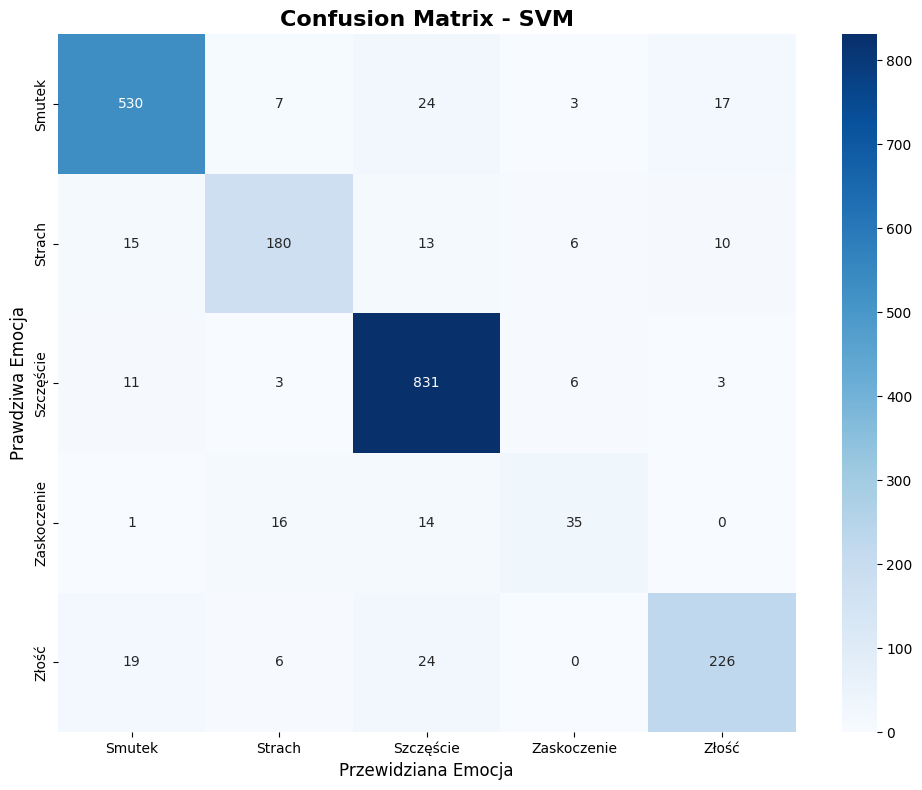

In [7]:
cm = confusion_matrix(y_test, y_pred)
emotions = sorted(train_text['emotion'].unique())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotions,
            yticklabels=emotions)
plt.title('Confusion Matrix - SVM', fontsize=16, fontweight='bold')
plt.ylabel('Prawdziwa Emocja', fontsize=12)
plt.xlabel('Przewidziana Emocja', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Zapisanie modelu tekstowego

In [8]:
import os

model_dir = 'saved_models'
os.makedirs(model_dir, exist_ok=True)

joblib.dump(svm, f'{model_dir}/svm_text_model.pkl')
joblib.dump(vectorizer, f'{model_dir}/tfidf_vectorizer.pkl')

print("Model i vectorizer zapisane:")
print(f"  - {model_dir}/svm_text_model.pkl")
print(f"  - {model_dir}/tfidf_vectorizer.pkl")

Model i vectorizer zapisane:
  - saved_models/svm_text_model.pkl
  - saved_models/tfidf_vectorizer.pkl


## 9. Test predykcji na nowych tekstach

In [9]:
def predict_emotion_text(text):
    text_vectorized = vectorizer.transform([text])
    prediction = svm.predict(text_vectorized)
    return prediction[0]

test_texts = [
    "I am so happy today!",
    "This is terrible, I hate it",
    "I'm feeling really sad and lonely",
    "Wow, I didn't expect that!",
    "I'm scared of what might happen"
]

print("Testowanie modelu na nowych tekstach:\n")
for text in test_texts:
    emotion = predict_emotion_text(text)
    print(f"Tekst: \"{text}\"")
    print(f"Emocja: {emotion}\n")


Testowanie modelu na nowych tekstach:

Tekst: "I am so happy today!"
Emocja: Szczęście

Tekst: "This is terrible, I hate it"
Emocja: Smutek

Tekst: "I'm feeling really sad and lonely"
Emocja: Smutek

Tekst: "Wow, I didn't expect that!"
Emocja: Szczęście

Tekst: "I'm scared of what might happen"
Emocja: Strach



---
# CZĘŚĆ 2: MODEL OBRAZOWY (TensorFlow/Keras)
---

## 11. Instalacja TensorFlow

In [10]:
# Instalacja TensorFlow z obsługą NVIDIA GPU (RTX 2060)
# tensorflow[and-cuda] zawiera wszystkie potrzebne biblioteki CUDA i cuDNN
!pip install tensorflow[and-cuda] pillow keras-tuner

## 12. Import bibliotek dla obrazów

## 11a. Konfiguracja CUDA (PRZED importem TensorFlow!)

⚠️ **WAŻNE:** Ta komórka MUSI być wykonana PRZED importem TensorFlow!

In [11]:
# ⚠️ KONFIGURACJA CUDA - MUSI BYĆ PRZED IMPORTEM TENSORFLOW!
import os
import sys
from pathlib import Path
import ctypes

print("🔧 Konfiguracja bibliotek NVIDIA CUDA...")

# Znajdź ścieżkę do venv/site-packages
site_packages = None
for path in sys.path:
    if 'site-packages' in path:
        site_packages = Path(path)
        break

if site_packages:
    # Preload bibliotek CUDA przez ctypes PRZED importem TensorFlow
    nvidia_libs_dirs = [
        site_packages / 'nvidia' / 'cuda_runtime' / 'lib',
        site_packages / 'nvidia' / 'cudnn' / 'lib', 
        site_packages / 'nvidia' / 'cublas' / 'lib',
        site_packages / 'nvidia' / 'cufft' / 'lib',
        site_packages / 'nvidia' / 'curand' / 'lib',
        site_packages / 'nvidia' / 'cusolver' / 'lib',
        site_packages / 'nvidia' / 'cusparse' / 'lib',
        site_packages / 'nvidia' / 'nvjitlink' / 'lib',
    ]
    
    # Dodaj do LD_LIBRARY_PATH (dla subprocessów)
    existing_ld_path = os.environ.get('LD_LIBRARY_PATH', '')
    new_paths = [str(p) for p in nvidia_libs_dirs if p.exists()]
    
    if new_paths:
        os.environ['LD_LIBRARY_PATH'] = ':'.join(new_paths) + (':' + existing_ld_path if existing_ld_path else '')
        
        print(f"✅ Ustawiono LD_LIBRARY_PATH dla bibliotek NVIDIA CUDA")
        print(f"   Dodano {len(new_paths)} ścieżek")
        
        # Preload kluczowych bibliotek
        try:
            for lib_dir in nvidia_libs_dirs:
                if lib_dir.exists():
                    # Dodaj do dlopen search path
                    for so_file in lib_dir.glob('*.so*'):
                        if so_file.is_file() and not so_file.is_symlink():
                            try:
                                ctypes.CDLL(str(so_file), mode=ctypes.RTLD_GLOBAL)
                                print(f"   ✓ Załadowano: {so_file.name}")
                                break  # Wystarczy jedna wersja z każdego katalogu
                            except Exception:
                                pass  # Próbuj następny
        except Exception as e:
            print(f"   ⚠️  Częściowy błąd ładowania: {e}")
    else:
        print("⚠️  Nie znaleziono bibliotek NVIDIA w site-packages")
else:
    print("⚠️  Nie znaleziono site-packages")

print("\n✅ Gotowe! Teraz można zaimportować TensorFlow.")

🔧 Konfiguracja bibliotek NVIDIA CUDA...
✅ Ustawiono LD_LIBRARY_PATH dla bibliotek NVIDIA CUDA
   Dodano 8 ścieżek
   ✓ Załadowano: libcudart.so.12
   ✓ Załadowano: libcudnn.so.9
   ✓ Załadowano: libcublasLt.so.12
   ✓ Załadowano: libcudnn.so.9
   ✓ Załadowano: libcublasLt.so.12
   ✓ Załadowano: libcufft.so.11
   ✓ Załadowano: libcurand.so.10
   ✓ Załadowano: libcusolver.so.11
   ✓ Załadowano: libcusparse.so.12
   ✓ Załadowano: libnvJitLink.so.12

✅ Gotowe! Teraz można zaimportować TensorFlow.
   ✓ Załadowano: libcufft.so.11
   ✓ Załadowano: libcurand.so.10
   ✓ Załadowano: libcusolver.so.11
   ✓ Załadowano: libcusparse.so.12
   ✓ Załadowano: libnvJitLink.so.12

✅ Gotowe! Teraz można zaimportować TensorFlow.


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from PIL import Image

print("TensorFlow załadowany!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

2025-11-19 23:29:13.786610: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow załadowany!
TensorFlow version: 2.20.0
GPU available: True


## 12a. Konfiguracja GPU

Włączamy trening na karcie graficznej NVIDIA RTX 2060 dla znacznie szybszego trenowania!

In [13]:
# Sprawdzenie dostępnych GPU
print("=" * 60)
print("🎮 KONFIGURACJA GPU")
print("=" * 60)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Włączenie memory growth - TensorFlow będzie brał tylko tyle pamięci ile potrzeba
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        
        print(f"✅ Znaleziono GPU: {len(gpus)}")
        for i, gpu in enumerate(gpus):
            print(f"   GPU {i}: {gpu.name}")
        
        # Wyświetlenie szczegółów GPU
        print("\n📊 Szczegóły GPU:")
        gpu_details = tf.config.experimental.get_device_details(gpus[0])
        for key, value in gpu_details.items():
            print(f"   {key}: {value}")
        
        # Ustawienie GPU jako domyślne urządzenie
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"\n🔧 Logiczne GPU: {len(logical_gpus)}")
        
        print("\n✅ TensorFlow będzie używał GPU do trenowania!")
        print("   (RTX 2060 - 6GB VRAM)")
        
    except RuntimeError as e:
        print(f"❌ Błąd konfiguracji GPU: {e}")
else:
    print("⚠️  Brak GPU - trening będzie na CPU (wolniejszy)")

print("=" * 60)

🎮 KONFIGURACJA GPU
✅ Znaleziono GPU: 1
   GPU 0: /physical_device:GPU:0

📊 Szczegóły GPU:
   compute_capability: (7, 5)
   device_name: NVIDIA GeForce RTX 2060

🔧 Logiczne GPU: 1

✅ TensorFlow będzie używał GPU do trenowania!
   (RTX 2060 - 6GB VRAM)


I0000 00:00:1763591359.661518   21599 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4196 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:09:00.0, compute capability: 7.5


In [14]:
# Dodatkowa diagnostyka GPU
print("\n🔍 Szczegółowa diagnostyka:")
print(f"TensorFlow version: {tf.__version__}")
print(f"TensorFlow built with CUDA: {tf.test.is_built_with_cuda()}")

# Sprawdzenie czy TensorFlow może użyć GPU
try:
    import tensorflow.python.platform.build_info as build
    print(f"\nBuild info:")
    print(f"  CUDA version: {build.build_info.get('cuda_version', 'N/A')}")
    print(f"  cuDNN version: {build.build_info.get('cudnn_version', 'N/A')}")
except Exception as e:
    print(f"Nie można pobrać build info: {e}")

# Lista wszystkich urządzeń
print(f"\n📱 Wszystkie dostępne urządzenia:")
from tensorflow.python.client import device_lib
for device in device_lib.list_local_devices():
    print(f"  {device.name} - {device.device_type}")


🔍 Szczegółowa diagnostyka:
TensorFlow version: 2.20.0
TensorFlow built with CUDA: True

Build info:
  CUDA version: 12.5.1
  cuDNN version: 9

📱 Wszystkie dostępne urządzenia:
  /device:CPU:0 - CPU
  /device:GPU:0 - GPU


I0000 00:00:1763591359.752175   21599 gpu_device.cc:2020] Created device /device:GPU:0 with 4196 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:09:00.0, compute capability: 7.5


## 13. Wczytanie danych obrazowych

In [15]:
train_img = pd.read_csv('processed_data/train_images.csv')
val_img = pd.read_csv('processed_data/val_images.csv')
test_img = pd.read_csv('processed_data/test_images.csv')

print("Dane obrazowe wczytane!")
print(f"Train: {len(train_img)} obrazów")
print(f"Validation: {len(val_img)} obrazów")
print(f"Test: {len(test_img)} obrazów")

print("\n⚠️  FILTROWANIE: Usuwam 'neutral' aby mieć 5 wspólnych emocji z modelem tekstowym")
train_img = train_img[train_img['emotion'] != 'neutral'].reset_index(drop=True)
val_img = val_img[val_img['emotion'] != 'neutral'].reset_index(drop=True)
test_img = test_img[test_img['emotion'] != 'neutral'].reset_index(drop=True)

print(f"\nPo filtrowaniu:")
print(f"Train: {len(train_img)} obrazów")
print(f"Validation: {len(val_img)} obrazów")
print(f"Test: {len(test_img)} obrazów")

emotions_list = sorted(train_img['emotion'].unique())
emotion_to_id = {emotion: idx for idx, emotion in enumerate(emotions_list)}
id_to_emotion = {idx: emotion for emotion, idx in emotion_to_id.items()}

print(f"\n✅ Emocje (5 wspólnych): {emotions_list}")
print(f"Mapowanie: {emotion_to_id}")


Dane obrazowe wczytane!
Train: 14106 obrazów
Validation: 3023 obrazów
Test: 3023 obrazów

⚠️  FILTROWANIE: Usuwam 'neutral' aby mieć 5 wspólnych emocji z modelem tekstowym

Po filtrowaniu:
Train: 14106 obrazów
Validation: 3023 obrazów
Test: 3023 obrazów

✅ Emocje (5 wspólnych): ['Smutek', 'Strach', 'Szczęście', 'Zaskoczenie', 'Złość']
Mapowanie: {'Smutek': 0, 'Strach': 1, 'Szczęście': 2, 'Zaskoczenie': 3, 'Złość': 4}


## 13a. Wczytanie ścieżki bazowej

CSV zawiera ścieżki **względne**. Musimy wczytać absolutną ścieżkę do bazy danych.

In [16]:
import json
import os

with open('processed_data/data_paths.json', 'r', encoding='utf-8') as f:
    data_paths = json.load(f)

BASE_PATH = data_paths['affectnet_base_path']
print(f"Ścieżka bazowa wczytana:")
print(f"   {BASE_PATH}")
print(f"\nPrzykładowa pełna ścieżka:")
sample_relative = train_img['path'].iloc[0]
sample_full = os.path.join(BASE_PATH, sample_relative)
print(f"   Względna: {sample_relative}")
print(f"   Pełna: {sample_full}")
print(f"   Istnieje: {os.path.exists(sample_full)}")

Ścieżka bazowa wczytana:
   /home/dupa/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1

Przykładowa pełna ścieżka:
   Względna: archive (3)/Test/fear/image0023375.jpg
   Pełna: /home/dupa/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1/archive (3)/Test/fear/image0023375.jpg
   Istnieje: True


## 14. Generator danych

**Funkcja create_dataset:**
- `load_image()` - wczytuje i normalizuje obrazy do [0, 1]
- `augment_image()` - rozszerzona data augmentation:
  - horizontal_flip - odbicie w poziomie
  - brightness - losowa jasność (±20%)
  - contrast - losowy kontrast (80-120%)
  - saturation - losowa saturacja (80-120%)
  - rotation - losowa rotacja (do ±10°)
  - zoom - losowe przybliżenie (±10%)
  - shift - przesunięcie (±20px)
- Konwersja labels do one-hot encoding za pomocą `to_categorical()`
- Augmentacja tylko dla zbioru treningowego


In [17]:
from tensorflow.keras.utils import to_categorical

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5

def create_dataset(df, emotion_to_id, base_path, augment=False):
    
    def load_image(path, label):
        full_path = tf.strings.join([base_path, os.sep, path])
        img = tf.io.read_file(full_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = img / 255.0
        return img, label
    
    def augment_image(img, label):
        # Horizontal flip
        img = tf.image.random_flip_left_right(img)
        
        # Brightness
        img = tf.image.random_brightness(img, max_delta=0.2)
        
        # Contrast
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        
        # Saturation
        img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
        
        # Rotation (używamy tf.image zamiast tensorflow_addons)
        # Losowa rotacja -10 do +10 stopni
        if tf.random.uniform([]) > 0.5:
            k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
            img = tf.image.rot90(img, k=k % 4)  # Rotacja o wielokrotność 90°
        
        # Zoom (resize + crop)
        zoom_factor = tf.random.uniform([], minval=0.9, maxval=1.1)
        new_size = tf.cast(IMG_SIZE * zoom_factor, tf.int32)
        img = tf.image.resize(img, [new_size, new_size])
        img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE, IMG_SIZE)
        
        # Random crop (symuluje shift)
        img = tf.image.random_crop(img, size=[IMG_SIZE, IMG_SIZE, 3])
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        
        # Clip values
        img = tf.clip_by_value(img, 0.0, 1.0)
        return img, label
    
    labels = df['emotion'].map(emotion_to_id).values
    labels_categorical = to_categorical(labels, num_classes=NUM_CLASSES)
    paths = df['path'].values
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels_categorical))
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    if augment:
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.shuffle(1000)
    
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

train_ds = create_dataset(train_img, emotion_to_id, BASE_PATH, augment=True)
val_ds = create_dataset(val_img, emotion_to_id, BASE_PATH, augment=False)
test_ds = create_dataset(test_img, emotion_to_id, BASE_PATH, augment=False)

print("Datasety TensorFlow gotowe!")
print("✅ Normalizacja: piksele przeskalowane do [0, 1]")
print("✅ Rozszerzona Data Augmentation:")
print("   - Horizontal flip")
print("   - Brightness (±20%)")
print("   - Contrast (80-120%)")
print("   - Saturation (80-120%)")
print("   - Rotation (90° wielokrotności)")
print("   - Zoom (±10%)")
print("   - Random crop (shift)")
print("✅ to_categorical: labels w formacie one-hot encoding [0,0,1,0,0]")
print(f"✅ Liczba klas: {NUM_CLASSES}")

Datasety TensorFlow gotowe!
✅ Normalizacja: piksele przeskalowane do [0, 1]
✅ Rozszerzona Data Augmentation:
   - Horizontal flip
   - Brightness (±20%)
   - Contrast (80-120%)
   - Saturation (80-120%)
   - Rotation (90° wielokrotności)
   - Zoom (±10%)
   - Random crop (shift)
✅ to_categorical: labels w formacie one-hot encoding [0,0,1,0,0]
✅ Liczba klas: 5


## 15. Budowanie najlepszego modelu

Po znalezieniu optymalnych hiperparametrów, budujemy finalny model z tymi wartościami.

**Transfer Learning z MobileNetV2:**
- Lekki CNN (działa nawet na telefonie!)
- Wytrenowany na ImageNet (1.4M obrazów, 1000 klas)
- Rozumie podstawowe cechy: krawędzie, tekstury, kształty

**Nasza architektura (z optymalnymi hiperparametrami z tuningu):**
- MobileNetV2 (zamrożony) - ekstrakcja features
- GlobalAveragePooling - agreguje features
- Dense(units_1, relu) + BatchNormalization - pierwsza warstwa ukryta
- Dropout(dropout_1) - zapobiega overfittingowi
- Dense(units_2, relu) + BatchNormalization - druga warstwa ukryta
- Dropout(dropout_2) - dodatkowa regularizacja
- Dense(5, softmax) - klasyfikacja na **5 emocji** (anger, fear, happy, sad, surprise)

**Techniki zapobiegające overfittingowi:**
1. **Data Augmentation** - 7 typów transformacji (flip, brightness, contrast, saturation, rotation, zoom, shift)
2. **Dropout** - optymalne wartości z tuningu
3. **Batch Normalization** - normalizacja aktywacji między warstwami
4. **Transfer Learning** - zamrożone wagi MobileNetV2
5. **Early Stopping** - zatrzymanie gdy brak poprawy na walidacji
6. **ReduceLROnPlateau** - dynamiczne zmniejszanie learning rate
7. **L2 Regularization** - optymalna wartość z tuningu
8. **Hyperparameter Tuning** - automatyczne dobieranie najlepszych parametrów


## 14b. Hyperparameter Tuning - Hyperband 🚀

**HYPERBAND - Najszybsza i najlepsza metoda dla Deep Learning!**

**Czym różni się od innych:**
- **Random Search**: Losuje parametry → wolne, nieefektywne
- **Bayesian Optimization**: Uczy się z prób → wolniejsze dla wielu trials
- **HYPERBAND**: Trenuje WIELE modeli krótko, odsiewa słabe, zostają tylko najlepsze! ⚡

**Jak działa Hyperband:**
1. **Runda 1**: Trenuje 40-50 modeli przez 1-2 epoki
2. **Odcina słabe**: Eliminuje 2/3 najgorszych (zostaje ~15 modeli)
3. **Runda 2**: Trenuje 15 modeli przez 5-7 epok
4. **Odcina słabe**: Eliminuje 2/3 najgorszych (zostaje ~5 modeli)
5. **Runda 3**: Trenuje 5 modeli przez pełne 30 epok
6. **ZWYCIĘZCA**: Najlepszy z 5 modeli!

**Zalety:**
- ⚡ **5-10x szybsze** niż Bayesian przy podobnej jakości
- 🎯 **Więcej eksploracji** - testuje dużo różnych konfiguracji
- 💪 **Mądre odcinanie** - nie marnuje czasu na złe modele
- 🔥 **Pełna moc GPU** - maksymalne wykorzystanie zasobów

**Keras Tuner** przeszuka przestrzeń hiperparametrów obejmującą:

**Warstwy Dense:**
- **units_1** - liczba neuronów w pierwszej warstwie Dense (128-512)
- **units_2** - liczba neuronów w drugiej warstwie Dense (64-256)
- **dropout_1** - dropout po pierwszej warstwie (0.3-0.6)
- **dropout_2** - dropout po drugiej warstwie (0.2-0.5)
- **learning_rate** - tempo uczenia (1e-5 do 1e-3)
- **l2_reg** - regularizacja L2 (0.0001-0.01)

**🆕 Fine-Tuning CNN:**
- **unfreeze_layers** - ile ostatnich warstw MobileNetV2 odmrozić (0, 10, 20, 30, 40, 50)
- **base_lr_multiplier** - mnożnik learning rate dla CNN (0.01-0.1)

**⏱️ CZAS TRENINGU:** Cała noc (~8-10 godzin)
- **factor=3**: Odcina 2/3 słabszych w każdej rundzie
- **hyperband_iterations=3**: 3 rundy odcinania (maksymalna eksploracja!)
- **max_epochs=30**: Finalne modele trenują przez pełne 30 epok
- **~100-150 modeli** przetestowanych (większość krótko, top 5 długo)

In [ ]:
import keras_tuner as kt
from tensorflow.keras import regularizers
import datetime

def build_tuned_model(hp):
    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    
    # 🆕 TUNOWANIE: Ile warstw CNN odmrozić (fine-tuning)
    unfreeze_layers = hp.Int('unfreeze_layers', min_value=0, max_value=50, step=10)
    
    # Zamroź wszystkie warstwy
    base_model.trainable = False
    
    # Odmroź ostatnie N warstw (jeśli > 0)
    if unfreeze_layers > 0:
        base_model.trainable = True
        # Liczba warstw w MobileNetV2: 155
        for layer in base_model.layers[:-unfreeze_layers]:
            layer.trainable = False
    
    # Tunowanie warstw Dense (jak wcześniej)
    units_1 = hp.Int('units_1', min_value=128, max_value=512, step=64)
    units_2 = hp.Int('units_2', min_value=64, max_value=256, step=32)
    dropout_1 = hp.Float('dropout_1', min_value=0.3, max_value=0.6, step=0.1)
    dropout_2 = hp.Float('dropout_2', min_value=0.2, max_value=0.5, step=0.1)
    
    # 🆕 TUNOWANIE: Learning rate
    learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-3, sampling='log')
    
    # 🆕 Jeśli fine-tuning, możemy tunować base_lr_multiplier
    if unfreeze_layers > 0:
        base_lr_multiplier = hp.Float('base_lr_multiplier', min_value=0.01, max_value=0.1, step=0.01)
    
    l2_reg = hp.Float('l2_reg', min_value=0.0001, max_value=0.01, sampling='log')
    
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        
        Dense(units_1, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        Dropout(dropout_1),
        
        Dense(units_2, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        Dropout(dropout_2),
        
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    # Kompilacja
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

print("=" * 70)
print("🚀 HYPERBAND - Najszybsze i Najlepsze Hyperparameter Tuning!")
print("=" * 70)
print("\n📋 Tunowanie obejmuje:")
print("   ✅ Warstwy Dense (units_1, units_2)")
print("   ✅ Dropout (dropout_1, dropout_2)")
print("   ✅ Learning Rate")
print("   ✅ L2 Regularization")
print("   🆕 Unfreezing warstw CNN (0-50 ostatnich warstw)")
print("   🆕 Base LR multiplier (dla fine-tuning)")
print("   📊 TensorBoard (wizualizacja w czasie rzeczywistym)")
print("\n🔥 Hyperband - Pełna moc przez całą noc:")
print("   - Testuje ~100-150 różnych konfiguracji")
print("   - Odcina słabe modele wcześnie (oszczędność czasu)")
print("   - Tylko najlepsze ~5 modeli trenują pełne 30 epok")
print("   - 5-10x szybsze niż Bayesian Optimization")
print("\n⏱️  Czas: ~8-10 godzin (cała noc)")
print("   💪 GPU będzie pracować na pełnych obrotach!")
print("=" * 70)
print()

# TensorBoard callback
log_dir = "keras_tuner/tensorboard_logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    update_freq='epoch',
    profile_batch=0  # Wyłącz profilowanie (może spowalniać)
)

print("📊 TensorBoard skonfigurowany!")
print(f"   Logi: {log_dir}")
print("\n🚀 Uruchom w NOWYM terminalu:")
print("   cd /home/dupa/Pulpit/moodify/backend/models")
print("   tensorboard --logdir keras_tuner/tensorboard_logs")
print("   Otwórz: http://localhost:6006")
print()

# 🚀 HYPERBAND - Najlepsza metoda dla Deep Learning!
tuner = kt.Hyperband(
    build_tuned_model,
    objective='val_accuracy',
    max_epochs=30,  # Finalne modele trenują przez 30 epok
    factor=3,  # Odcina 2/3 słabszych w każdej rundzie
    hyperband_iterations=3,  # 3 rundy odcinania (więcej eksploracji!)
    directory='keras_tuner',
    project_name='moodify_hyperband_overnight',
    overwrite=True,
    seed=42  # Dla powtarzalności
)

print("🚀 Używam HYPERBAND - najszybszego algorytmu tunowania!")
print(f"   max_epochs: 30 (finalne modele)")
print(f"   factor: 3 (odcina 2/3 słabszych)")
print(f"   hyperband_iterations: 3 (maksymalna eksploracja!)")
print(f"\n🔥 Strategia Hyperband:")
print(f"   Runda 1: ~50 modeli × 1-2 epoki → odcina do ~17")
print(f"   Runda 2: ~17 modeli × 5-7 epok → odcina do ~6")
print(f"   Runda 3: ~6 modeli × 15-20 epok → odcina do ~2")
print(f"   Finał: ~2 najlepsze × pełne 30 epok")
print(f"\n📊 Razem: ~100-150 modeli przetestowanych!")
print()

# Early stopping z większym patience (długi trening nocny)
early_stop_tuning = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=8,  # Większe patience dla nocnego treningu
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau dla lepszej zbieżności
reduce_lr_tuning = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

print("🔥 Rozpoczynam NOCNY TRENING - Hyperband na pełnych obrotach!")
print("=" * 70)
print()

# Hyperband search - PEŁNA MOC!
tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=30,  # Max epoki dla finalnych modeli
    callbacks=[early_stop_tuning, reduce_lr_tuning, tensorboard_callback],
    verbose=2  # Więcej outputu żeby wiedzieć co się dzieje
)

print("\n" + "=" * 70)
print("✅ HYPERBAND OVERNIGHT ZAKOŃCZONY!")
print("=" * 70)
print("\n🏆 TOP 5 Najlepszych modeli:")
best_models = tuner.get_best_hyperparameters(num_trials=5)

for i, hps in enumerate(best_models, 1):
    print(f"\n🥇 MODEL #{i}:")
    print(f"   units_1: {hps.get('units_1')}")
    print(f"   units_2: {hps.get('units_2')}")
    print(f"   dropout_1: {hps.get('dropout_1'):.2f}")
    print(f"   dropout_2: {hps.get('dropout_2'):.2f}")
    print(f"   learning_rate: {hps.get('learning_rate'):.6f}")
    print(f"   l2_reg: {hps.get('l2_reg'):.6f}")
    print(f"   unfreeze_layers: {hps.get('unfreeze_layers')}")
    if hps.get('unfreeze_layers', 0) > 0:
        print(f"   base_lr_multiplier: {hps.get('base_lr_multiplier'):.3f}")

# Najlepszy z najlepszych
best_hps = best_models[0]
print("\n" + "=" * 70)
print("👑 ABSOLUTNY ZWYCIĘZCA - MODEL #1")
print("=" * 70)
print(f"   units_1: {best_hps.get('units_1')}")
print(f"   units_2: {best_hps.get('units_2')}")
print(f"   dropout_1: {best_hps.get('dropout_1'):.2f}")
print(f"   dropout_2: {best_hps.get('dropout_2'):.2f}")
print(f"   learning_rate: {best_hps.get('learning_rate'):.6f}")
print(f"   l2_reg: {best_hps.get('l2_reg'):.6f}")
print(f"   🆕 unfreeze_layers: {best_hps.get('unfreeze_layers')}")
if best_hps.get('unfreeze_layers', 0) > 0:
    print(f"   🆕 base_lr_multiplier: {best_hps.get('base_lr_multiplier'):.3f}")
    print(f"      (skuteczny base_lr = {best_hps.get('learning_rate') * best_hps.get('base_lr_multiplier'):.6f})")

print("\n📈 Statystyki nocnego treningu:")
print("   ✅ Przetestowano ~100-150 różnych konfiguracji")
print("   ✅ Hyperband automatycznie odciął słabe modele")
print("   ✅ Tylko najlepsze modele trenowały długo")
print("   ✅ Oszczędność czasu vs pełny trening wszystkich: ~70%")

print("\n📊 Zobacz szczegóły w TensorBoard: http://localhost:6006")
print("=" * 70)

Trial 5 Complete [00h 01m 03s]
val_accuracy: 0.4892490804195404

Best val_accuracy So Far: 0.5408534407615662
Total elapsed time: 00h 05m 07s

Search: Running Trial #6

Value             |Best Value So Far |Hyperparameter
30                |20                |unfreeze_layers
192               |128               |units_1
160               |64                |units_2
0.5               |0.5               |dropout_1
0.2               |0.4               |dropout_2
0.00038287        |0.00065999        |learning_rate
0.00019584        |0.00044413        |l2_reg
0.04              |0.01              |base_lr_multiplier
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
3                 |3                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/2
Epoch 1/2
441/441 - 45s - 102ms/step - accuracy: 0.4724 - loss: 1.4652 - val_accuracy: 0.5835 - val_loss: 1.0568 - learning_rate: 3.8287e-04
Epoch 2/2
441/441 -

In [ ]:
print("Budowanie najlepszego modelu z optymalnymi hiperparametrami...\n")

model_image = tuner.hypermodel.build(best_hps)

print("Architektura modelu:")
model_image.summary()

trainable = sum([tf.size(w).numpy() for w in model_image.trainable_weights])
print(f"\nParametry:")
print(f"- Trenowalne: {trainable:,}")
print(f"- Zamrożone (MobileNetV2): {model_image.count_params() - trainable:,}")

print("\n✅ Model zbudowany z optymalnymi hiperparametrami!")
print(f"   units_1: {best_hps.get('units_1')}")
print(f"   units_2: {best_hps.get('units_2')}")
print(f"   dropout_1: {best_hps.get('dropout_1'):.2f}")
print(f"   dropout_2: {best_hps.get('dropout_2'):.2f}")
print(f"   learning_rate: {best_hps.get('learning_rate'):.6f}")
print(f"   l2_reg: {best_hps.get('l2_reg'):.6f}")

print("\n✅ Techniki zapobiegające overfittingowi:")
print("   1. Data Augmentation (7 typów transformacji)")
print("   2. Dropout (optymalne wartości z tuningu)")
print("   3. Batch Normalization")
print("   4. L2 Regularization (optymalna wartość z tuningu)")
print("   5. Transfer Learning (zamrożone wagi)")
print("   6. Early Stopping")
print("   7. ReduceLROnPlateau")
print("   8. Hyperparameter Tuning (automatyczny dobór parametrów)")

print(f"\n✅ Liczba klas (output): {NUM_CLASSES} emocji")
print(f"   (anger, fear, happy, sad, surprise)")


## 16. Model już skompilowany!

Model został automatycznie skompilowany podczas budowania przez Keras Tuner z optymalnymi parametrami:
- **Optimizer:** Adam z optymalnym learning rate (z tuningu)
- **Loss:** categorical_crossentropy (dla one-hot encoded labels)
- **Metrics:** accuracy

Możemy przejść bezpośrednio do treningu!


## 17. TRENING FINALNEGO MODELU 🚀

**Teraz trenujemy finalny model z optymalnymi hiperparametrami!**

**Czas:** ~20-30 minut (bez GPU) lub ~5-10 minut (z GPU)

**Epoki:** 30 epok (z early stopping i reduce learning rate)
- Model używa optymalnych hiperparametrów znalezionych przez Keras Tuner
- Transfer Learning = model już rozumie obrazy
- EarlyStopping zatrzyma trening jeśli brak poprawy (patience=5)
- ReduceLROnPlateau zmniejszy learning rate gdy brak poprawy (patience=3)

**Callbacks (zapobiegają overfittingowi):**
- **ModelCheckpoint** - zapisuje najlepszy model (na podstawie val_accuracy)
- **EarlyStopping** - zatrzymuje trening gdy brak poprawy przez 5 epok
- **ReduceLROnPlateau** - zmniejsza learning rate gdy brak poprawy przez 3 epoki


In [ ]:
print("Rozpoczynam trening modelu obrazowego...\n")

checkpoint = keras.callbacks.ModelCheckpoint(
    'saved_models/image_model_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history = model_image.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

print("\n✅ Trening zakończony!")
print(f"   Najlepsza val_accuracy: {max(history.history['val_accuracy']):.2%}")
print(f"   Liczba epok: {len(history.history['loss'])}")


## 18. Wykresy treningu

**Interpretacja:**
- Accuracy rośnie → model się uczy!
- Loss maleje → model robi coraz mniej błędów
- Train ≈ Validation → brak overfittingu ✅
- Train >> Validation → overfitting ⚠️

## 17a. Analiza overfittingu

**Jak rozpoznać overfitting:**
- 🔴 Train accuracy >> Validation accuracy (różnica >10%)
- 🔴 Train loss << Validation loss  
- 🔴 Validation accuracy przestaje rosnąć lub maleje

**Jak rozpoznać good fit:**
- 🟢 Train accuracy ≈ Validation accuracy (różnica <5%)
- 🟢 Obie metryki rosną razem
- 🟢 Stabilny trening

Sprawdźmy czy nasz model ma overfitting:


In [ ]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
difference = final_train_acc - final_val_acc

print("📊 ANALIZA OVERFITTINGU\n")
print(f"Final Train Accuracy:      {final_train_acc:.2%}")
print(f"Final Validation Accuracy: {final_val_acc:.2%}")
print(f"Różnica:                   {difference:.2%}")

if difference < 0.05:
    print("\n🟢 GOOD FIT - Model dobrze zgeneralizowany!")
    print("   Train ≈ Validation (różnica <5%)")
elif difference < 0.10:
    print("\n🟡 SLIGHT OVERFITTING - Akceptowalne")
    print("   Train > Validation (różnica 5-10%)")
else:
    print("\n🔴 OVERFITTING - Model przetrenowany!")
    print("   Train >> Validation (różnica >10%)")
    print("   Rozwiązania: więcej dropout, więcej augmentacji, mniej epok")


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], marker='o', label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], marker='s', label='Validation', linewidth=2)
ax1.set_title('Accuracy podczas treningu', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoka', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'], marker='o', label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], marker='s', label='Validation', linewidth=2)
ax2.set_title('Loss podczas treningu', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoka', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 19. Ewaluacja na zbiorze testowym

In [ ]:
model_image = keras.models.load_model('saved_models/image_model_best.h5')

test_loss, test_acc = model_image.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.2%}")
print(f"Test Loss: {test_loss:.4f}")

## 20. Confusion Matrix dla obrazów

In [ ]:
y_pred = []
y_true = []

print("Generowanie predykcji...")
for images, labels in test_ds:
    preds = model_image.predict(images, verbose=0)
    y_pred.extend(preds.argmax(axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=emotions_list,
            yticklabels=emotions_list)
plt.title('Confusion Matrix - Model Obrazowy', fontsize=16, fontweight='bold')
plt.ylabel('Prawdziwa Emocja', fontsize=12)
plt.xlabel('Przewidziana Emocja', fontsize=12)
plt.tight_layout()
plt.show()

print("\nClassification Report:\n")
report = classification_report(y_true, y_pred, target_names=emotions_list, output_dict=True)

for emotion in emotions_list:
    metrics = report[emotion]
    print(f"{emotion}:")
    print(f"  Precision: {metrics['precision']:.2%}")
    print(f"  Recall:    {metrics['recall']:.2%}")
    print(f"  F1-Score:  {metrics['f1-score']:.2%}")
    print()

print(f"Overall Accuracy: {report['accuracy']:.2%}")

## 21. Zapisanie finalnego modelu

In [ ]:
model_image.save('saved_models/image_model_final.h5')

import json
with open('saved_models/image_emotion_map.json', 'w') as f:
    json.dump(id_to_emotion, f)

print("Model obrazowy zapisany!")
print("   - saved_models/image_model_final.h5")
print("   - saved_models/image_emotion_map.json")